In [4]:
from arraylake import Client
import xarray as xr

client = Client()
repo = client.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")




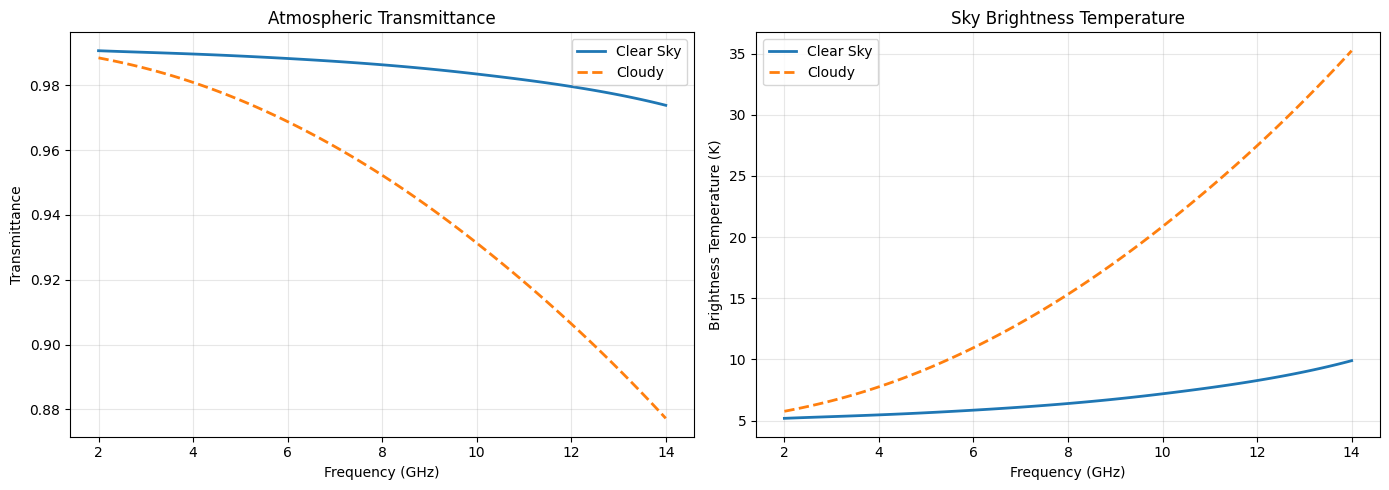

Maximum transmittance change : 0.096513
Mean transmittance change    : 0.039283

Maximum Tb change            : 25.346 K
Mean Tb change               : 10.313 K


In [6]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

AM_EXE = os.path.join(BASE, "am.exe")

CLEAR_AMC = os.path.join(BASE, "clear.amc.txt")
CLOUD_AMC = os.path.join(BASE, "cloud.amc.txt")

# ==========================================================
# RUN AM
# ==========================================================

def run_am(amc_file):

    result = subprocess.run(
        [AM_EXE, amc_file],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr)

    freq = []
    tx = []
    tb = []

    for line in result.stdout.splitlines():

        line = line.strip()

        if len(line) == 0:
            continue

        if line[0] in "#!?":
            continue

        s = line.split()

        if len(s) < 3:
            continue

        try:
            freq.append(float(s[0]))
            tx.append(float(s[1]))
            tb.append(float(s[2]))
        except:
            pass

    return (
        np.asarray(freq),
        np.asarray(tx),
        np.asarray(tb),
    )

# ==========================================================
# RUN BOTH ATMOSPHERES
# ==========================================================

freq_clear, tx_clear, tb_clear = run_am(CLEAR_AMC)

freq_cloud, tx_cloud, tb_cloud = run_am(CLOUD_AMC)

# ==========================================================
# PLOT
# ==========================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------------------------------------
# Transmittance
# ----------------------------------------------------------

ax[0].plot(
    freq_clear,
    tx_clear,
    lw=2,
    label="Clear Sky"
)

ax[0].plot(
    freq_cloud,
    tx_cloud,
    "--",
    lw=2,
    label="Cloudy"
)

ax[0].set_xlabel("Frequency (GHz)")
ax[0].set_ylabel("Transmittance")
ax[0].set_title("Atmospheric Transmittance")
ax[0].grid(alpha=0.3)
ax[0].legend()

# ----------------------------------------------------------
# Brightness Temperature
# ----------------------------------------------------------

ax[1].plot(
    freq_clear,
    tb_clear,
    lw=2,
    label="Clear Sky"
)

ax[1].plot(
    freq_cloud,
    tb_cloud,
    "--",
    lw=2,
    label="Cloudy"
)

ax[1].set_xlabel("Frequency (GHz)")
ax[1].set_ylabel("Brightness Temperature (K)")
ax[1].set_title("Sky Brightness Temperature")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# ==========================================================
# PRINT DIFFERENCES
# ==========================================================

print("=" * 60)
print(f"Maximum transmittance change : {np.max(np.abs(tx_clear - tx_cloud)):.6f}")
print(f"Mean transmittance change    : {np.mean(np.abs(tx_clear - tx_cloud)):.6f}")
print()
print(f"Maximum Tb change            : {np.max(np.abs(tb_clear - tb_cloud)):.3f} K")
print(f"Mean Tb change               : {np.mean(np.abs(tb_clear - tb_cloud)):.3f} K")
print("=" * 60)

In [7]:
import xarray
import numpy as np

# 1. Initialize dataset using the provided code
ds = xarray.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_full_37_1h = ds.sel(time=slice(ds.attrs.get('valid_time_start', '1959-01-01'), ds.attrs.get('valid_time_stop', '2023-12-31')))

# 2. Fetch exactly ONE time chunk (time=0) to prevent massive memory usage
# The chunk-1 dataset is chunked individually by time.
ds_single_chunk = ar_full_37_1h.isel(time=0)

print("Downloading the 3D grid for a single hour (this will take a few seconds)...")
# Load only humidity and cloud liquid water into memory
q_data = ds_single_chunk['specific_humidity'].load()
clwc_data = ds_single_chunk['specific_cloud_liquid_water_content'].load()

# 3. Aggregate across all 37 pressure levels to get a column total proxy
column_cloud = clwc_data.sum(dim='level')
column_moisture = q_data.sum(dim='level')

# 4. Find the Cloudiest Place on the grid (Max cloud liquid water)
cloud_arr = column_cloud.values
max_cloud_idx = np.unravel_index(np.nanargmax(cloud_arr), cloud_arr.shape)

cloudy_lat = column_cloud.latitude.values[max_cloud_idx[0]]
cloudy_lon = column_cloud.longitude.values[max_cloud_idx[1]]
cloud_max_val = cloud_arr[max_cloud_idx]

# 5. Find the Driest Place on the grid (Min specific humidity)
moist_arr = column_moisture.values
min_moist_idx = np.unravel_index(np.nanargmin(moist_arr), moist_arr.shape)

dry_lat = column_moisture.latitude.values[min_moist_idx[0]]
dry_lon = column_moisture.longitude.values[min_moist_idx[1]]
moist_min_val = moist_arr[min_moist_idx]

# 6. Output the results
print("\n--- Results for Time Chunk 0 ---")
print(f"Cloudiest Location:")
print(f"  Coordinates: Lat {cloudy_lat}°, Lon {cloudy_lon}°")
print(f"  Sum of CLWC across levels: {cloud_max_val:.6e} kg/kg")

print(f"\nDriest Location:")
print(f"  Coordinates: Lat {dry_lat}°, Lon {dry_lon}°")
print(f"  Sum of Specific Humidity across levels: {moist_min_val:.6e} kg/kg")

c:\Users\Darkrai\Projects\torch_env\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\Darkrai\Projects\torch_env\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\Darkrai\Projects\torch_env\lib\site-packages\google\api_core\_python_versio


--- Results for Time Chunk 0 ---
Cloudiest Location:
  Coordinates: Lat 28.25°, Lon 89.5°
  Sum of CLWC across levels: 1.785759e-02 kg/kg

Driest Location:
  Coordinates: Lat 78.0°, Lon 299.75°
  Sum of Specific Humidity across levels: 1.389900e-03 kg/kg


Opened datasets.
Pressure vars: ['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind'] ...
Single vars   : ['cape', 'd2m', 'hcc', 'istl1', 'istl2', 'istl3', 'istl4', 'lcc', 'mcc', 'msl', 'p79.162', 'p80.162', 'siconc', 'skt', 'sp', 'sst', 'stl1', 'stl2', 'stl3', 'stl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 't2m', 'tcc', 'tciw', 'tclw', 'tcrw', 'tcsw', 'tcw', 'tcwv', 'tsn', 'u10', 'u100', 'v10', 'v100', 'z']

Cloudiest point:
  idx   = 0
  lat/lon = (89.7849, 0.0000)
  sp    = nan Pa
  tclw  = 0.000000 kg/m^2
  tciw  = 0.000000 kg/m^2
  tcrw  = 0.000000 kg/m^2
  tcsw  = 0.000000 kg/m^2
  tcwv  = 0.000000 kg/m^2

Driest point:
  idx   = 0
  lat/lon = (89.7849, 0.0000)
  sp    = nan Pa
  tclw  = 0.000000 kg/m^2
  tciw  = 0.000000 kg/m^2
  tcrw  = 0.000000 kg/m^2
  tcsw  = 0.000000 kg/m^2
  tcwv  = 0.000000 kg/m^2

Building profiles and running AM...
Driest     lat/lon=(89.7849, 0.0000) LWP=0.

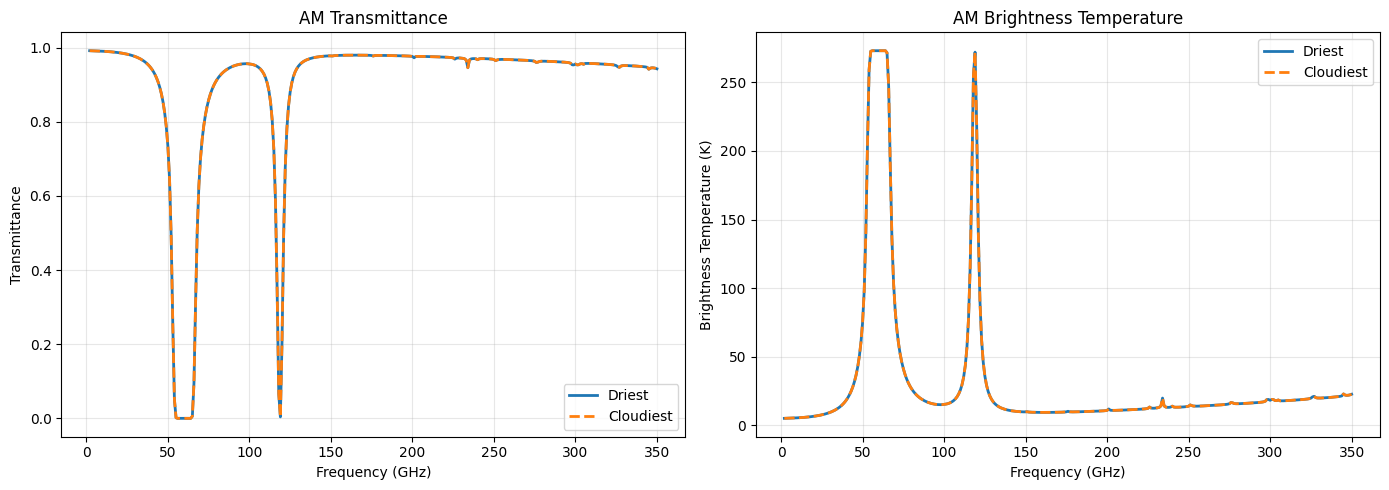


Mean |ΔTx| : 0.0
Max  |ΔTx| : 0.0
Mean |ΔTb| : 0.0 K
Max  |ΔTb| : 0.0 K


In [13]:
import os
import tempfile
import subprocess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
AM_EXE = os.path.join(BASE, "am.exe")

# ==========================================================
# DATASET PATHS
# ==========================================================

PRESSURE_ZARR = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
SINGLE_ZARR   = "gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr-v2"

# ==========================================================
# SETTINGS
# ==========================================================

LAT = 26.4967
LON = 80.2413
TIME_IDX = 59000            # one hour only, just for testing

# Wide band so cloud effects are easier to see
FREQ_MIN = 2.0
FREQ_MAX = 350.0
FREQ_STEP = 1.0

g = 9.80665
epsilon = 0.622

# ==========================================================
# OPEN DATASETS
# ==========================================================

pressure = xr.open_zarr(
    PRESSURE_ZARR,
    chunks=None,
    storage_options={"token": "anon"},
    decode_timedelta=True
)

single = xr.open_zarr(
    SINGLE_ZARR,
    chunks=None,
    storage_options={"token": "anon"},
    decode_timedelta=True
)

pressure_t = pressure.isel(time=TIME_IDX)
single_t = single.isel(time=TIME_IDX)

print("Opened datasets.")
print("Pressure vars:", list(pressure.data_vars)[:5], "...")
print("Single vars   :", list(single.data_vars))
print()

# ==========================================================
# EXTRACT AND SANITIZE ARRAYS
# ==========================================================

print("Downloading single-level data arrays (this may take a few seconds)...")
sp_vals   = single_t["sp"].values
tclw_vals = np.nan_to_num(single_t["tclw"].values, nan=0.0)
tciw_vals = np.nan_to_num(single_t["tciw"].values, nan=0.0)
tcrw_vals = np.nan_to_num(single_t["tcrw"].values, nan=0.0)
tcsw_vals = np.nan_to_num(single_t["tcsw"].values, nan=0.0)
tcwv_vals = np.nan_to_num(single_t["tcwv"].values, nan=0.0)

# ==========================================================
# FIND CLOUDIEST / DRIEST POINT AT THIS HOUR
# ==========================================================

cloud_metric = tclw_vals + tciw_vals + tcrw_vals + tcsw_vals

cloudiest_idx = int(np.argmax(cloud_metric))
driest_idx = int(np.argmin(cloud_metric))

def summarize_point(idx, label):
    lat_pt = float(single_t.latitude.values[idx])
    lon_pt = float(single_t.longitude.values[idx])
    sp   = float(sp_vals[idx])
    tclw = float(tclw_vals[idx])
    tciw = float(tciw_vals[idx])
    tcrw = float(tcrw_vals[idx])
    tcsw = float(tcsw_vals[idx])
    tcwv = float(tcwv_vals[idx])

    print(f"{label}:")
    print(f"  idx   = {idx}")
    print(f"  lat/lon = ({lat_pt:.4f}, {lon_pt:.4f})")
    print(f"  sp    = {sp:.2f} Pa")
    print(f"  tclw  = {tclw:.6f} kg/m^2")
    print(f"  tciw  = {tciw:.6f} kg/m^2")
    print(f"  tcrw  = {tcrw:.6f} kg/m^2")
    print(f"  tcsw  = {tcsw:.6f} kg/m^2")
    print(f"  tcwv  = {tcwv:.6f} kg/m^2")
    print()

summarize_point(cloudiest_idx, "Cloudiest point")
summarize_point(driest_idx, "Driest point")

# ==========================================================
# HELPERS
# ==========================================================

def get_pressure_profile_at(lat_pt, lon_pt):
    """
    Extract pressure-level profile at the nearest grid point.
    Returns pressure levels in Pa, temperature in K, specific humidity in kg/kg.
    """
    prof = pressure_t.sel(
        latitude=lat_pt,
        longitude=lon_pt,
        method="nearest",
    )

    level_name = None
    for name in ["level", "isobaricInhPa", "isobaricInPa"]:
        if name in prof.coords or name in prof.dims:
            level_name = name
            break
    if level_name is None:
        raise ValueError("Could not find pressure level coordinate name.")

    prof = prof.sortby(level_name)
    p_raw = prof[level_name].values.astype(np.float64)

    if np.nanmax(p_raw) < 2000:
        p_pa = p_raw * 100.0
    else:
        p_pa = p_raw

    T = np.nan_to_num(prof["temperature"].values.astype(np.float64), nan=273.15)
    q = np.nan_to_num(prof["specific_humidity"].values.astype(np.float64), nan=0.0)
    Z = np.nan_to_num(prof["geopotential"].values.astype(np.float64), nan=0.0)

    return p_pa, T, q, Z


def build_amc_text(p_pa, T, q, sp_pa, lwp, iwp, title):
    """
    Build an AM config file from pressure-level T/q plus a surface pressure insertion.
    Guarantees strict monotonic pressure ordering and truncates underground levels.
    """
    # 1. Fallback for missing surface pressure
    if np.isnan(sp_pa) or sp_pa <= 0:
        sp_pa = 101325.0

    # Convert specific humidity to VMR and clamp to zero
    vmr = q / (epsilon + (1.0 - epsilon) * q)
    vmr = np.clip(vmr, 0.0, None)

    # Sort ascending pressure (AM file will go low pressure -> high pressure)
    order = np.argsort(p_pa)
    p_pa = p_pa[order]
    T = T[order]
    vmr = vmr[order]

    sp_pa = float(sp_pa)

    # 2. Interpolate surface values BEFORE truncating the profile
    # np.interp requires strictly increasing x-coordinates, which we now have.
    ts = np.interp(sp_pa, p_pa, T)
    vs = np.interp(sp_pa, p_pa, vmr)

    # 3. Truncate "underground" levels
    # Keep only pressure levels strictly less than the actual surface pressure.
    valid_idx = p_pa < sp_pa
    p_valid = p_pa[valid_idx]
    T_valid = T[valid_idx]
    V_valid = vmr[valid_idx]

    # 4. Append the true surface layer at the very bottom
    p_all = np.append(p_valid, sp_pa)
    T_all = np.append(T_valid, ts)
    V_all = np.append(V_valid, vs)

    # Put cloud absorption in a representative layer near 700 hPa (70000 Pa)
    cloud_idx = int(np.argmin(np.abs(p_all - 70000.0)))

    lines = []
    lines.append(f"# {title}")
    lines.append(f"f {FREQ_MIN} GHz {FREQ_MAX} GHz {FREQ_STEP} GHz")
    lines.append("output f GHz tau Tb K")
    lines.append("T0 2.7 K")
    lines.append("za 0 deg")
    lines.append("")

    for k, (p, t, v) in enumerate(zip(p_all, T_all, V_all)):
        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {t:.3f} K")

        # Cloud absorption (stress test)
        if k == cloud_idx:
            if lwp > 0 and not np.isnan(lwp):
                lines.append(f"column lwp_abs_Rayleigh {lwp:.6g} kg*m^-2")
            if iwp > 0 and not np.isnan(iwp):
                lines.append(f"column iwp_abs_Rayleigh {iwp:.6g} kg*m^-2")

        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {v:.8e}")
        lines.append("")

    return "\n".join(lines)


def run_am(amc_text, label):
    """
    Write AM config to a temp file, run AM, parse stdout columns:
    frequency, transmittance, Tb
    """
    with tempfile.TemporaryDirectory() as d:
        amc_path = os.path.join(d, f"{label}.amc")
        with open(amc_path, "w", encoding="utf-8") as f:
            f.write(amc_text)

        result = subprocess.run(
            [AM_EXE, amc_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )

        freq = []
        tx = []
        tb = []

        # Parse STDOUT even if there is a non-zero return code, 
        # because AM returns non-zero codes for harmless warnings.
        for line in result.stdout.splitlines():
            line = line.strip()
            if not line:
                continue
            if line[0] in "#!?":
                continue

            parts = line.split()
            if len(parts) < 3:
                continue

            try:
                freq.append(float(parts[0]))
                
                # AM outputs tau. We compute transmittance as exp(-tau)
                tau_val = float(parts[1])
                tx.append(np.exp(-tau_val))
                
                tb.append(float(parts[2]))
            except ValueError:
                pass
                
        # Only crash if we failed to parse any valid data
        if len(freq) == 0:
            raise RuntimeError(
                f"AM model failed to produce output for '{label}'.\n"
                f"Return Code: {result.returncode}\n"
                f"--- STDERR ---\n{result.stderr}\n"
                f"--- STDOUT ---\n{result.stdout}"
            )

    return (
        np.asarray(freq, dtype=np.float64),
        np.asarray(tx, dtype=np.float64),
        np.asarray(tb, dtype=np.float64),
    )

# ==========================================================
# BUILD TWO CASES
# ==========================================================

cases = {}

print("Building profiles and running AM...")
for name, idx in [("cloudiest", cloudiest_idx), ("driest", driest_idx)]:
    lat_pt = float(single_t.latitude.values[idx])
    lon_pt = float(single_t.longitude.values[idx])

    # Pressure profile at nearest pressure-grid location
    p_pa, T, q, Z = get_pressure_profile_at(lat_pt, lon_pt)

    # Single-level values at the chosen flattened point
    sp = float(sp_vals[idx])
    
    # Sanitize missing surface pressure before it hits builder
    if np.isnan(sp):
        sp = 101325.0

    # Lump rain water into liquid and snow water into ice for this stress test
    lwp = float(tclw_vals[idx] + tcrw_vals[idx])
    iwp = float(tciw_vals[idx] + tcsw_vals[idx])

    amc_text = build_amc_text(
        p_pa=p_pa,
        T=T,
        q=q,
        sp_pa=sp,
        lwp=lwp,
        iwp=iwp,
        title=f"{name.capitalize()} case at time index {TIME_IDX}",
    )

    freq, tx, tb = run_am(amc_text, name)

    cases[name] = {
        "idx": idx,
        "lat": lat_pt,
        "lon": lon_pt,
        "sp": sp,
        "lwp": lwp,
        "iwp": iwp,
        "freq": freq,
        "tx": tx,
        "tb": tb,
        "amc": amc_text,
    }

# ==========================================================
# PRINT QUICK SUMMARY
# ==========================================================

print("=" * 80)
for name in ["driest", "cloudiest"]:
    c = cases[name]
    print(
        f"{name.capitalize():<10} "
        f"lat/lon=({c['lat']:.4f}, {c['lon']:.4f}) "
        f"LWP={c['lwp']:.6f} kg/m^2 "
        f"IWP={c['iwp']:.6f} kg/m^2 "
        f"freq_pts={len(c['freq'])}"
    )
print("=" * 80)

# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(cases["driest"]["freq"], cases["driest"]["tx"], lw=2, label="Driest")
axes[0].plot(cases["cloudiest"]["freq"], cases["cloudiest"]["tx"], "--", lw=2, label="Cloudiest")
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel("Transmittance")
axes[0].set_title("AM Transmittance")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(cases["driest"]["freq"], cases["driest"]["tb"], lw=2, label="Driest")
axes[1].plot(cases["cloudiest"]["freq"], cases["cloudiest"]["tb"], "--", lw=2, label="Cloudiest")
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Brightness Temperature (K)")
axes[1].set_title("AM Brightness Temperature")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================================
# PRINT DIFFERENCES
# ==========================================================

tx_diff = np.abs(cases["cloudiest"]["tx"] - cases["driest"]["tx"])
tb_diff = np.abs(cases["cloudiest"]["tb"] - cases["driest"]["tb"])

print()
print("Mean |ΔTx| :", float(np.mean(tx_diff)))
print("Max  |ΔTx| :", float(np.max(tx_diff)))
print("Mean |ΔTb| :", float(np.mean(tb_diff)), "K")
print("Max  |ΔTb| :", float(np.max(tb_diff)), "K")